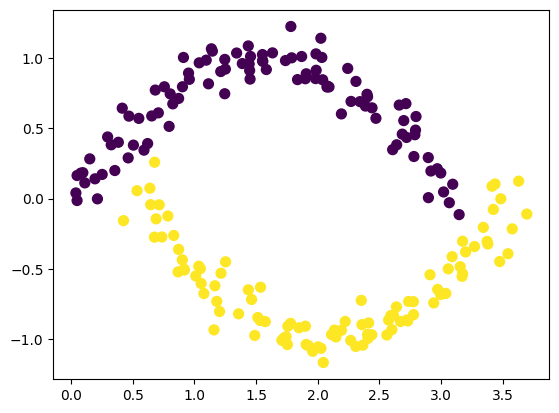

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Class 0 (upper curved cluster)
theta = np.linspace(0, np.pi, 100)
x0 = np.c_[theta, np.sin(theta)] + np.random.randn(100, 2) * 0.1

# Class 1 (lower curved cluster)
theta = np.linspace(0, np.pi, 100)
x1 = np.c_[theta + 0.5, -np.sin(theta)] + np.random.randn(100, 2) * 0.1

# Combine
X = np.vstack((x0, x1))
y = np.array([0]*100 + [1]*100)

# Shuffle
perm = np.random.permutation(len(X))
X = X[perm]
y = y[perm]

# Plot to verify (should look like your image)
plt.scatter(X[:,0], X[:,1], c=y, s=50)
plt.show()

In [2]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [3]:
model=Sequential()
model.add(Dense(2, activation='relu', input_dim=2))
model.add(Dense(1, activation='sigmoid'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9 (36.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

In [4]:
model.get_weights()

[array([[ 0.28475332, -0.76017797],
        [ 1.130046  , -1.0933816 ]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[-1.398022  ],
        [-0.00685072]], dtype=float32),
 array([0.], dtype=float32)]

In [5]:
inw=model.get_weights()

In [6]:
inw[0]=np.zeros(model.get_weights()[0].shape)
inw[1]=np.zeros(model.get_weights()[1].shape)
inw[2]=np.zeros(model.get_weights()[2].shape)
inw[3]=np.zeros(model.get_weights()[3].shape)

In [7]:
model.set_weights(inw)

In [8]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [9]:
model.fit(X,y, epochs=100, validation_split=0.2)

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.4875 - loss: 0.6932 - val_accuracy: 0.4500 - val_loss: 0.6932
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5125 - loss: 0.6932 - val_accuracy: 0.4500 - val_loss: 0.6932
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5125 - loss: 0.6931 - val_accuracy: 0.4500 - val_loss: 0.6932
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5125 - loss: 0.6931 - val_accuracy: 0.4500 - val_loss: 0.6933
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5125 - loss: 0.6931 - val_accuracy: 0.4500 - val_loss: 0.6933
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5125 - loss: 0.6931 - val_accuracy: 0.4500 - val_loss: 0.6933
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5125 - loss: 0.6931 - val_accuracy: 0.4500 - val_loss: 0.6933
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5125 - loss: 0.6931 - val_accuracy: 0.4500 - val_loss:

In [10]:
model.get_weights()

[array([[0., 0.],
        [0., 0.]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[0.],
        [0.]], dtype=float32),
 array([0.03970138], dtype=float32)]

# **Now Lets do with Tanh(Zero initialization)**

In [11]:
model1=Sequential()
model1.add(Dense(2, activation='tanh', input_dim=2))
model1.add(Dense(1, activation='sigmoid'))

model1.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9 (36.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
inw=model1.get_weights()
inw[0]=np.zeros(model1.get_weights()[0].shape)
inw[1]=np.zeros(model1.get_weights()[1].shape)
inw[2]=np.zeros(model1.get_weights()[2].shape)
inw[3]=np.zeros(model1.get_weights()[3].shape)
model1.set_weights(inw)

In [ ]:
model1.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model1.fit(X,y, epochs=100, validation_split=0.2)

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.4875 - loss: 0.6932 - val_accuracy: 0.4500 - val_loss: 0.6933
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5125 - loss: 0.6931 - val_accuracy: 0.4500 - val_loss: 0.6933
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5125 - loss: 0.6931 - val_accuracy: 0.4500 - val_loss: 0.6934
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5125 - loss: 0.6931 - val_accuracy: 0.4500 - val_loss: 0.6934
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5125 - loss: 0.6931 - val_accuracy: 0.4500 - val_loss: 0.6934
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5125 - loss: 0.6931 - val_accuracy: 0.4500 - val_loss: 0.6934
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5125 - loss: 0.6931 - val_accuracy: 0.4500 - val_loss: 0.6935
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5125 - loss: 0.6931 - val_accuracy: 0.4500 - val_loss:

In [ ]:
model1.get_weights()

[array([[0., 0.],
        [0., 0.]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[0.],
        [0.]], dtype=float32),
 array([0.04094518], dtype=float32)]

# **Lets do with Sigmoid(Zero initialization)**

In [ ]:
model2=Sequential()
model2.add(Dense(2, activation='sigmoid', input_dim=2))
model2.add(Dense(1, activation='sigmoid'))

model2.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9 (36.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model2.get_weights()

[array([[-0.5899105,  0.7279197],
        [ 0.5027888, -1.0475354]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[ 1.1071452],
        [-0.9176286]], dtype=float32),
 array([0.], dtype=float32)]

In [ ]:
inw=model2.get_weights()
inw[0]=np.zeros(model2.get_weights()[0].shape)
inw[1]=np.zeros(model2.get_weights()[1].shape)
inw[2]=np.zeros(model2.get_weights()[2].shape)
inw[3]=np.zeros(model2.get_weights()[3].shape)
model2.set_weights(inw)

In [ ]:
model2.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model2.fit(X,y, epochs=100, validation_split=0.2)

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.4500 - val_loss: 0.6933
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5125 - loss: 0.6931 - val_accuracy: 0.4500 - val_loss: 0.6934
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5125 - loss: 0.6931 - val_accuracy: 0.4500 - val_loss: 0.6935
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5125 - loss: 0.6931 - val_accuracy: 0.4500 - val_loss: 0.6936
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5125 - loss: 0.6930 - val_accuracy: 0.4500 - val_loss: 0.6936
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5125 - loss: 0.6930 - val_accuracy: 0.4500 - val_loss: 0.6937
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5125 - loss: 0.6930 - val_accuracy: 0.4500 - val_loss: 0.6938
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5125 - loss: 0.6929 - val_accuracy: 0.4500 - val_loss:

In [ ]:
model2.get_weights()

[array([[ 0.24124265,  0.24124265],
        [-0.83456457, -0.83456457]], dtype=float32),
 array([-0.32378456, -0.32378456], dtype=float32),
 array([[0.27976906],
        [0.27976906]], dtype=float32),
 array([-0.08732872], dtype=float32)]

# **Non Zero constant weight initialization**

In [ ]:
model3=Sequential()
model3.add(Dense(2, activation='relu', input_dim=2))
model3.add(Dense(1, activation='sigmoid'))

model3.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9 (36.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model3.get_weights()

[array([[-0.31542164, -0.47995132],
        [ 0.32060707,  0.19901562]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[0.44190526],
        [0.46675408]], dtype=float32),
 array([0.], dtype=float32)]

In [ ]:
inw=model3.get_weights()
inw[0]=np.ones(model3.get_weights()[0].shape)*0.5
inw[1]=np.ones(model3.get_weights()[1].shape)*0.5
inw[2]=np.ones(model3.get_weights()[2].shape)*0.5
inw[3]=np.ones(model3.get_weights()[3].shape)*0.5
model3.set_weights(inw)

model3.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model3.fit(X,y, epochs=100, validation_split=0.2)

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.5125 - loss: 1.1776 - val_accuracy: 0.4500 - val_loss: 1.2595
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5125 - loss: 1.1652 - val_accuracy: 0.4500 - val_loss: 1.2446
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5125 - loss: 1.1505 - val_accuracy: 0.4500 - val_loss: 1.2305
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5125 - loss: 1.1385 - val_accuracy: 0.4500 - val_loss: 1.2164
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5125 - loss: 1.1258 - val_accuracy: 0.4500 - val_loss: 1.2026
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5125 - loss: 1.1139 - val_accuracy: 0.4500 - val_loss: 1.1889
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5125 - loss: 1.1019 - val_accuracy: 0.4500 - val_loss: 1.1755
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5125 - loss: 1.0892 - val_accuracy: 0.4500 - val_loss:

In [ ]:
model3.get_weights()

[array([[0.2592133 , 0.2592133 ],
        [0.10648357, 0.10648357]], dtype=float32),
 array([0.22223794, 0.22223794], dtype=float32),
 array([[0.20544443],
        [0.20544443]], dtype=float32),
 array([0.15138316], dtype=float32)]

# **Lets do with he/glorat init**

In [12]:
model3=Sequential()
model3.add(Dense(2, activation='relu', input_dim=2, kernel_initializer="he_normal"))
model3.add(Dense(1, activation='sigmoid', kernel_initializer="he_normal"))

model3.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9 (36.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

In [13]:
model3.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model3.fit(X,y, epochs=100, validation_split=0.2)

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - accuracy: 0.4875 - loss: 2.9643 - val_accuracy: 0.5500 - val_loss: 2.7853
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4875 - loss: 2.9118 - val_accuracy: 0.5500 - val_loss: 2.7426
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4875 - loss: 2.8649 - val_accuracy: 0.5500 - val_loss: 2.6992
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4875 - loss: 2.8149 - val_accuracy: 0.5500 - val_loss: 2.6564
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4875 - loss: 2.7639 - val_accuracy: 0.5500 - val_loss: 2.6141
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4875 - loss: 2.7165 - val_accuracy: 0.5250 - val_loss: 2.5716
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4812 - loss: 2.6680 - val_accuracy: 0.5250 - val_loss: 2.5291
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4812 - loss: 2.6194 - val_accuracy: 0.5250 - val_loss:

In [14]:
model3.get_weights()

[array([[ 1.6915051 ,  0.4061718 ],
        [-0.04322292, -2.099427  ]], dtype=float32),
 array([-0.30821222,  0.3688237 ], dtype=float32),
 array([[-1.4439563],
        [ 2.4351473]], dtype=float32),
 array([0.31348443], dtype=float32)]